# FinSight — 05 · Pipeline RAG (Retrieval-Augmented Generation)

**Objectif :** Construire un système qui répond aux questions sur les actifs financiers en s'appuyant sur les news récentes, via LangChain + FAISS + Mistral.

**Pourquoi RAG ?**
Mistral seul ne connaît pas ce qui s'est passé sur les marchés cette semaine. Le RAG lui fournit les articles récents comme contexte — il peut alors répondre avec des informations actualisées.

**Le pipeline en 3 étapes :**
```
Question → [Retrieval] → Chunks pertinents → [Augmentation] → Prompt → [Generation] → Réponse
```

**Plan :**
1. Configuration
2. Ingestion : articles → embeddings → index FAISS
3. Retrieval : recherche sémantique dans FAISS
4. Génération : RAG complet avec Mistral
5. Résumé automatique par actif
6. Évaluation qualitative du RAG

## 1. Configuration

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import json
import pandas as pd
from dotenv import load_dotenv
from pathlib import Path

from src.config import ALL_TICKERS, TICKER_LABELS, DATA_RAW_DIR, FAISS_INDEX_PATH
from src.rag.ingest import (
    load_news_json, build_article_text, chunk_text,
    prepare_corpus, build_faiss_index, load_faiss_index,
)
from src.rag.retriever import FinSightRetriever, generate_rag_response, summarize_ticker_news

load_dotenv('../.env')
print('Imports OK')

Imports OK


## 2. Ingestion : articles → embeddings → FAISS

**Étape 2.1 — Inspection des articles bruts**

In [2]:
# Aperçu des articles collectés par ticker
print('Articles disponibles par ticker :')
total = 0
for ticker in ALL_TICKERS:
    articles = load_news_json(ticker)
    total += len(articles)
    print(f'  {ticker:8s} ({TICKER_LABELS[ticker]:20s}) : {len(articles):3d} articles')
print(f'\nTotal : {total} articles')

Articles disponibles par ticker :
  MC.PA    (LVMH                ) :  44 articles
  TTE.PA   (TotalEnergies       ) :  28 articles
  AAPL     (Apple               ) :  98 articles
  MSFT     (Microsoft           ) :  96 articles
  GC=F     (Or (Gold)           ) : 100 articles
  SI=F     (Argent (Silver)     ) :   1 articles
  PL=F     (Platine (Platinum)  ) :   0 articles

Total : 367 articles


In [3]:
# Exemple d'un article AAPL
articles_aapl = load_news_json('AAPL')
article_exemple = articles_aapl[0]

print('=== Article brut ===')
for key, val in article_exemple.items():
    print(f'{key:15s}: {str(val)[:120]}')

print('\n=== Texte construit pour l\'embedding ===')
texte = build_article_text(article_exemple)
print(texte)

=== Article brut ===
ticker         : AAPL
title          : The Apple Studio Display could have been so much more
description    : For the better part of 12 years, Apple owned the 5K monitor world - primarily because it made basically the only options
content        : <ul><li></li><li></li><li></li></ul>
The Studio Display is barely changed from 2022, but now it has competition.
If yo
url            : https://www.theverge.com/tech/929015/apple-studio-display-2026
published_at   : 2026-05-13T03:20:23Z
source         : The Verge

=== Texte construit pour l'embedding ===
The Apple Studio Display could have been so much more | For the better part of 12 years, Apple owned the 5K monitor world - primarily because it made basically the only options. LG's 5K UltraFine was a solid, if bland choice, but many people bought a 27-inch iMac from 2014 for its 5K screen alone. Then in 2022, Ap… | <ul><li></li><li></li><li></li></ul>
The Studio Display is barely changed from 2022, but now it has compet

**Étape 2.2 — Chunking**

On découpe chaque article en chunks de ~800 caractères avec 100 caractères de chevauchement.

Pourquoi découper ?
- Les modèles d'embedding ont une fenêtre de contexte limitée (~512 tokens)
- Des chunks courts sont plus précis pour la recherche sémantique
- Le chevauchement évite de couper une phrase importante en deux

In [4]:
# Démonstration du chunking sur un article long
texte_long = texte * 3  # Simule un article plus long
chunks_demo = chunk_text(texte_long, chunk_size=800, overlap=100)

print(f'Texte original : {len(texte_long)} caractères')
print(f'Nombre de chunks : {len(chunks_demo)}')
for i, chunk in enumerate(chunks_demo):
    print(f'\n--- Chunk {i+1} ({len(chunk)} chars) ---')
    print(chunk[:150], '...' if len(chunk) > 150 else '')

Texte original : 1557 caractères
Nombre de chunks : 3

--- Chunk 1 (800 chars) ---
The Apple Studio Display could have been so much more | For the better part of 12 years, Apple owned the 5K monitor world - primarily because it made  ...

--- Chunk 2 (800 chars) ---
s 5K UltraFine was a solid, if bland choice, but many people bought a 27-inch iMac from 2014 for its 5K screen alone. Then in 2022, Ap… | <ul><li></li ...

--- Chunk 3 (157 chars) ---
tudio Display is barely changed from 2022, but now it has competition.
If you buy something from a Verge link, Vox Media may earn a commission. See o ...


In [5]:
# Préparation du corpus complet
chunks, metadata = prepare_corpus(ALL_TICKERS)

print(f'Corpus total : {len(chunks)} chunks')
print(f'\nDistribution par ticker :')
ticker_counts = {}
for m in metadata:
    ticker_counts[m['label']] = ticker_counts.get(m['label'], 0) + 1
for label, count in sorted(ticker_counts.items(), key=lambda x: -x[1]):
    print(f'  {label:20s} : {count} chunks')

print(f'\nExemple chunk :')
print(chunks[0][:300])

Corpus total : 367 chunks

Distribution par ticker :
  Or (Gold)            : 100 chunks
  Apple                : 98 chunks
  Microsoft            : 96 chunks
  LVMH                 : 44 chunks
  TotalEnergies        : 28 chunks
  Argent (Silver)      : 1 chunks

Exemple chunk :
LVMH Streamlines Portfolio In $850 Million Sale To WHP And G-III Apparel | LVMH has reached a definitive agreement to sell its stake in Marc Jacobs to WHP and G-III Apparel for $850 million. | LVMH is divesting Marc Jacobs in an $850 million sale to a newly formed joint venture between WHP Global an


**Étape 2.3 — Embeddings et index FAISS**

On utilise `all-MiniLM-L6-v2` : un modèle léger (22M paramètres) mais très performant pour la recherche sémantique en anglais. Il produit des vecteurs de dimension 384.

In [6]:
# Construction de l'index FAISS (télécharge le modèle au premier lancement)
print('Construction de l\'index FAISS...')
print('(Le modèle se télécharge au premier lancement — ~80MB)')

index, chunks, metadata = build_faiss_index(ALL_TICKERS, save=True)

print(f'\nIndex FAISS :')
print(f'  Vecteurs indexés : {index.ntotal}')
print(f'  Dimension        : {index.d}')
print(f'  Sauvegardé dans  : {FAISS_INDEX_PATH}')

Construction de l'index FAISS...
(Le modèle se télécharge au premier lancement — ~80MB)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Index FAISS :
  Vecteurs indexés : 367
  Dimension        : 384
  Sauvegardé dans  : /Users/kseniadautel/Desktop/projet_final/notebooks/../data/processed/faiss_index


## 3. Retrieval : recherche sémantique

In [7]:
# Initialisation du retriever
retriever = FinSightRetriever(index, chunks, metadata)
print('Retriever initialisé')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Retriever initialisé


In [8]:
# Test de recherche — question générale
query = "What are the latest news about Apple earnings and financial results?"
results = retriever.search(query, top_k=5)

print(f'Requête : "{query}"')
print(f'\n{len(results)} chunks trouvés :\n')

for i, r in enumerate(results, 1):
    print(f'--- Résultat {i} (score={r["score"]:.4f}) ---')
    print(f'Actif  : {r["label"]} ({r["ticker"]})')
    print(f'Source : {r["source"]} — {r["published_at"][:10]}')
    print(f'Titre  : {r["title"]}')
    print(f'Extrait: {r["chunk"][:200]}...')
    print()

Requête : "What are the latest news about Apple earnings and financial results?"

5 chunks trouvés :

--- Résultat 1 (score=0.5117) ---
Actif  : Apple (AAPL)
Source : 9to5Mac — 2026-05-14
Titre  : Intel is now making iPhone chips for Apple, per report
Extrait: Intel is now making iPhone chips for Apple, per report | Last week The Wall Street Journal reported that Apple and Intel had struck a deal to produce chips, and now a new report from Ming-Chi Kuo says...

--- Résultat 2 (score=0.4861) ---
Actif  : Apple (AAPL)
Source : 9to5Mac — 2026-05-13
Titre  : Apple spotlights people ‘making a difference in the Apple developer commiunity’
Extrait: Apple spotlights people ‘making a difference in the Apple developer commiunity’ | Ahead of WWDC 2026, which kicks off next month, Apple has updated its Apple Developer website to spotlight members of ...

--- Résultat 3 (score=0.4861) ---
Actif  : Apple (AAPL)
Source : CNET — 2026-05-19
Titre  : Think You Know Apple? Prove It in CNET's Big Guessing

In [9]:
# Test avec filtre ticker — uniquement les news LVMH
query_lvmh = "luxury market performance and consumer spending"
results_lvmh = retriever.search(query_lvmh, top_k=3, ticker_filter='MC.PA')

print(f'Requête : "{query_lvmh}" (filtre : LVMH uniquement)')
print(f'{len(results_lvmh)} résultats :\n')

for i, r in enumerate(results_lvmh, 1):
    print(f'{i}. [{r["score"]:.4f}] {r["title"][:80]}')
    print(f'   {r["chunk"][:150]}...')
    print()

Requête : "luxury market performance and consumer spending" (filtre : LVMH uniquement)
3 résultats :

1. [0.4524] How Coach became Gen Z’s favorite affordable luxury handbag brand
   How Coach became Gen Z’s favorite affordable luxury handbag brand | Coach has found the sweet spot between high luxury and good prices. | Styleobsesse...

2. [0.3384] Delphine Arnault on Dior’s Past, Present — and Plans for the Future
   Delphine Arnault on Dior’s Past, Present — and Plans for the Future | The brand's CEO talks about the importance of the U.S. market, working with Jona...

3. [0.3114] Chinese brands coming for Starbucks, Nike, and your wallet
   Chinese brands coming for Starbucks, Nike, and your wallet | From Luckin to Pop Mart, China's hottest companies are trying to become cool, build store...



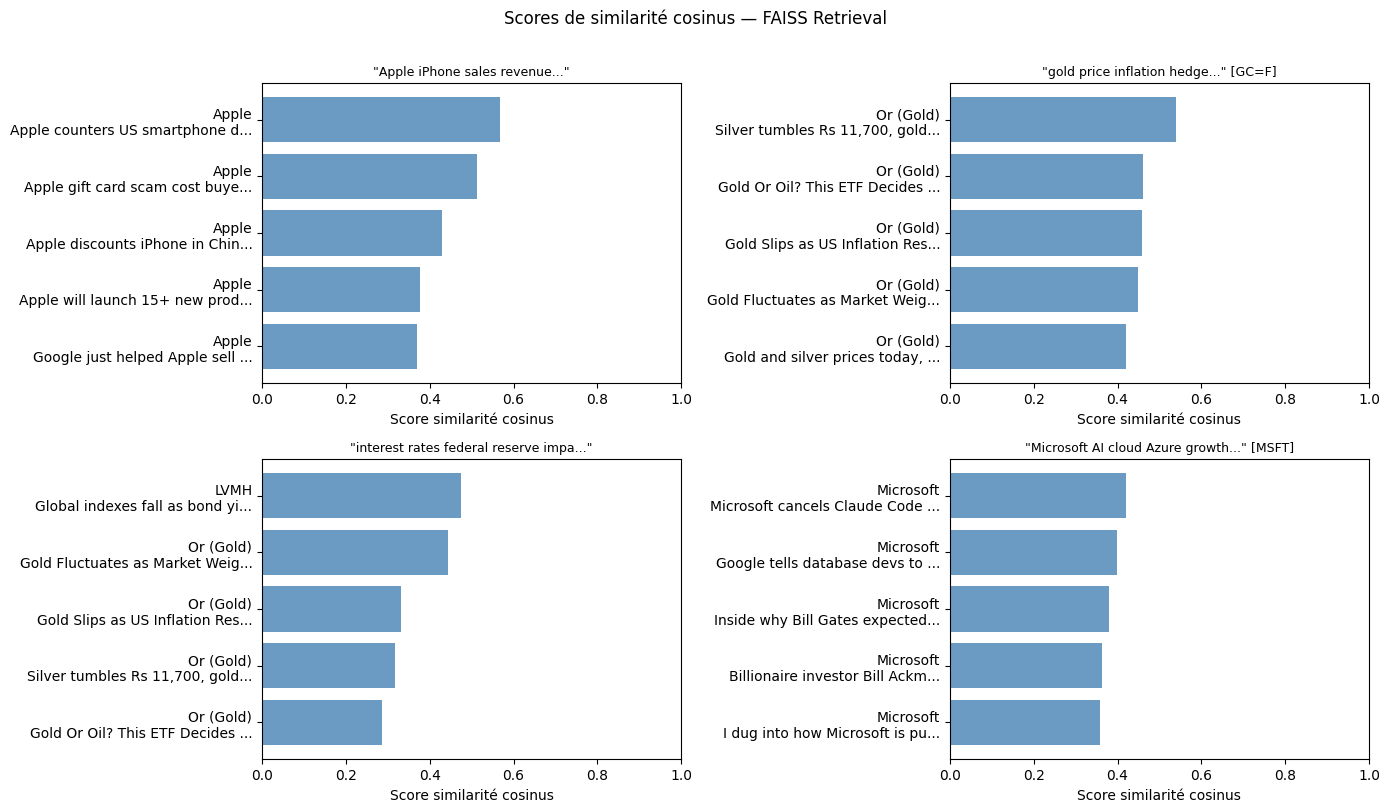

In [10]:
# Visualisation des scores de similarité
import matplotlib.pyplot as plt

queries_test = [
    ("Apple iPhone sales revenue", None),
    ("gold price inflation hedge", 'GC=F'),
    ("interest rates federal reserve impact", None),
    ("Microsoft AI cloud Azure growth", 'MSFT'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (query_t, filter_t) in zip(axes, queries_test):
    res = retriever.search(query_t, top_k=5, ticker_filter=filter_t)
    if not res:
        ax.text(0.5, 0.5, 'Aucun résultat', ha='center')
        ax.set_title(query_t[:40])
        continue
    labels_plot = [f"{r['label']}\n{r['title'][:30]}..." for r in res]
    scores_plot  = [r['score'] for r in res]
    ax.barh(labels_plot[::-1], scores_plot[::-1], color='steelblue', alpha=0.8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Score similarité cosinus')
    filter_info = f' [{filter_t}]' if filter_t else ''
    ax.set_title(f'"{query_t[:35]}..."{filter_info}', fontsize=9)

plt.suptitle('Scores de similarité cosinus — FAISS Retrieval', y=1.01)
plt.tight_layout()
plt.show()

## 4. Génération RAG complète avec Mistral

In [11]:
# RAG complet — question sur Apple
question = "Quelles sont les nouvelles importantes sur Apple cette semaine ?"

print(f'Question : {question}')
print('Génération en cours...\n')

result = generate_rag_response(
    query=question,
    retriever=retriever,
    ticker_filter='AAPL',
    top_k=5,
)

print('=== RÉPONSE MISTRAL ===')
print(result['response'])
print(f'\n({result["n_chunks_used"]} chunks utilisés comme contexte)')

Question : Quelles sont les nouvelles importantes sur Apple cette semaine ?
Génération en cours...

=== RÉPONSE MISTRAL ===
Voici les nouvelles importantes sur Apple cette semaine, basées uniquement sur les articles fournis :

1. **Promotion et réductions** :
   - Plusieurs produits Apple sont en promotion, notamment les **AirPods Max 2** (-40 $), le **MacBook Pro 2026** (jusqu'à -216 $), et l'**Apple Watch Series 11** (jusqu'à -130 $).
   - Des accessoires de recharge Anker (dont le nouveau **Prime 3-en-1**) sont également en promotion sur Amazon.

2. **Stratégie de gestion des puces défectueuses** :
   - Apple utilise une méthode appelée **"chip binning"** pour réutiliser des puces défectueuses dans d'autres modèles de produits ou même dans des produits différents, ce qui génère des revenus supplémentaires.

3. **Nouveaux produits et accessoires** :
   - Plusieurs accessoires pour Mac, iPhone et iPad ont été testés, comme le **Twelve South PlugBug 50**, le **Lexar Professional Go**, 

In [12]:
# Affichage des sources utilisées par Mistral
print('=== SOURCES UTILISÉES ===')
for i, source in enumerate(result['sources'], 1):
    print(f'{i}. [{source["label"]}] {source["title"]}')
    print(f'   Score : {source["score"]:.4f} | {source["source"]} — {source["published_at"][:10]}')
    if source['url']:
        print(f'   URL   : {source["url"]}')
    print()

=== SOURCES UTILISÉES ===
1. [Apple] heise+ | Kurztests: „Wo ist?“-Netzteil, iPhone-SSD, MacBook-Klappständer, Solar-Keyboard
   Score : 0.4505 | heise online — 2026-05-18
   URL   : https://www.heise.de/tests/Kurztests-Wo-ist-Netzteil-iPhone-SSD-MacBook-Klappstaender-Solar-Keyboard-11280344.html?wt_mc=rss.red.ho.ho.atom.beitrag_plus.beitrag_plus

2. [Apple] An Apple (II) for Teacher
   Score : 0.3144 | Technicshistory.com — 2026-05-19
   URL   : https://technicshistory.com/2026/05/19/an-apple-ii-for-teacher/

3. [Apple] Best Apple Deals of the Week: Anker Accessories on Sale Plus AirPods Max 2 for $509 and More
   Score : 0.2648 | MacRumors — 2026-05-16
   URL   : https://www.macrumors.com/2026/05/16/best-apple-deals-of-the-week-5-15-26/

4. [Apple] Apple promotes Creator Studio with three commissioned pieces
   Score : 0.2088 | 9to5Mac — 2026-05-14
   URL   : https://9to5mac.com/2026/05/14/apple-promotes-creator-studio-with-three-commissioned-pieces/

5. [Apple] Apple’s faulty chips 

In [13]:
# RAG sur une question macroéconomique
question_macro = "Quel est l'impact des taux d'intérêt sur l'or en ce moment ?"

result_macro = generate_rag_response(
    query=question_macro,
    retriever=retriever,
    ticker_filter='GC=F',
)

print(f'Question : {question_macro}')
print('\n=== RÉPONSE ===')
print(result_macro['response'])

Question : Quel est l'impact des taux d'intérêt sur l'or en ce moment ?

=== RÉPONSE ===
D'après les articles fournis, **aucun ne mentionne directement l'impact des taux d'intérêt sur le prix de l'or** en ce moment.

Les articles abordent :
- Une comparaison Bitcoin vs Or (sans lien avec les taux).
- Une hausse des ETF or/silver en Inde due à une augmentation des droits de douane (pas de mention des taux).
- Un ETF combinant or et pétrole (HGER) performant, mais sans explication sur les taux.
- Des sujets non financiers (Panasonic, IA, etc.).

**Conclusion** : Les données disponibles ne permettent pas de répondre à votre question.

*Les prédictions sont à titre informatif uniquement.*


## 5. Résumé automatique par actif

Cette fonction sera appelée par le dashboard Streamlit pour afficher
un résumé des news à côté de la prédiction ML.

In [14]:
# Résumé pour chaque actif avec news disponibles
tickers_with_news = ['AAPL', 'MSFT', 'MC.PA', 'TTE.PA', 'GC=F']

for ticker in tickers_with_news:
    print(f'\n{"="*60}')
    print(f'  {TICKER_LABELS[ticker]} ({ticker})')
    print(f'{"="*60}')
    result = summarize_ticker_news(ticker, retriever)
    print(result['response'])
    print(f'  (basé sur {result["n_chunks_used"]} chunks)')


  Apple (AAPL)
D'après les articles récents :

1. **Croissance des ventes d'iPhone** : Apple a surpassé le marché américain des smartphones au **T1 2026**, grâce à la demande persistante pour l'**iPhone 17**, dans un contexte de baisse des ventes Android (source : Article 2).

2. **Stratégie publicitaire** : Apple renforce son équipe **"Emerging Team"** pour attirer les développeurs et augmenter ses dépenses dans **Apple Ads** (source : Article 4).

3. **Innovation et accessoires** : Des tests ont été menés sur des accessoires pour Mac, iPhone et iPad, comme des claviers solaires ou des supports pour MacBook (source : Article 1).

4. **Histoire d'Apple** : L'**Apple II** a connu un succès fulgurant au début des années 1980, notamment grâce au logiciel **VisiCalc** (source : Article 3).

Les prédictions sont à titre informatif uniquement.
  (basé sur 5 chunks)

  Microsoft (MSFT)
Voici les points clés des dernières nouvelles concernant Microsoft (MSFT) :

1. **Enquête antitrust au Roya

## 6. Évaluation qualitative du RAG

On teste le RAG sur des questions dont on connaît la réponse attendue.

In [15]:
# Questions de test avec réponses attendues
test_questions = [
    {
        'question': "What is Apple's recent stock performance?",
        'ticker': 'AAPL',
        'expected_keywords': ['apple', 'stock', 'shares'],
    },
    {
        'question': "Is gold a good hedge against inflation currently?",
        'ticker': 'GC=F',
        'expected_keywords': ['gold', 'inflation', 'price'],
    },
    {
        'question': "What are the latest developments at Microsoft?",
        'ticker': 'MSFT',
        'expected_keywords': ['microsoft', 'ai', 'cloud'],
    },
]

print('=== ÉVALUATION QUALITATIVE DU RAG ===\n')

for i, test in enumerate(test_questions, 1):
    print(f'--- Test {i} ---')
    print(f'Question : {test["question"]}')

    result = generate_rag_response(
        query=test['question'],
        retriever=retriever,
        ticker_filter=test['ticker'],
    )

    # Vérification simple : les mots-clés attendus sont-ils dans la réponse ?
    response_lower = result['response'].lower()
    found = [kw for kw in test['expected_keywords'] if kw in response_lower]
    coverage = len(found) / len(test['expected_keywords'])

    print(f'Réponse : {result["response"][:200]}...')
    print(f'Mots-clés couverts : {found} ({coverage:.0%})')
    print(f'Sources utilisées  : {result["n_chunks_used"]} chunks')
    print()

=== ÉVALUATION QUALITATIVE DU RAG ===

--- Test 1 ---
Question : What is Apple's recent stock performance?
Réponse : D'après les articles fournis, **aucune information** n'est donnée concernant la performance récente du stock d'Apple.

Les articles mentionnent des rumeurs sur de nouveaux produits (iPhone 18, iPad mi...
Mots-clés couverts : ['apple', 'stock'] (67%)
Sources utilisées  : 5 chunks

--- Test 2 ---
Question : Is gold a good hedge against inflation currently?
Réponse : D'après les articles fournis :

- **L'or baisse** en raison de **l'inflation élevée** et des **tensions géopolitiques** (Article 1, 3).
- **Les prix de l'énergie** (un composant clé de l'inflation) on...
Mots-clés couverts : ['inflation'] (33%)
Sources utilisées  : 5 chunks

--- Test 3 ---
Question : What are the latest developments at Microsoft?
Réponse : Voici les dernières évolutions chez Microsoft, selon les articles récents :

1. **Concurrence accrue sur Windows 11** :
   - Google prépare le lancement des 

## Conclusions

**Ce qu'on a construit :**

1. **Ingestion** : 367 articles → chunks de 800 chars → embeddings 384D → index FAISS
2. **Retrieval** : recherche en ~10ms par similarité cosinus
3. **Génération** : Mistral répond en français en se basant uniquement sur les articles récents

**Limites observées :**
- SI=F (Argent) et PL=F (Platine) ont très peu d'articles → réponses moins riches
- NewsAPI free tier limite à 100 articles par requête et 7 jours en arrière

**Prochaine étape :** `src/agent/finsight_agent.py` — combiner ML + RAG dans un agent conversationnel LangChain.